# Step 2 · Silver ➜ **Gold** — the business layer

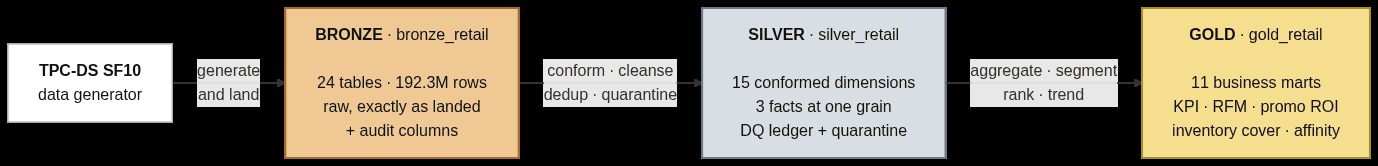

Gold answers **business questions**. Nothing here cleans or models anything — silver
already did that, and gold is allowed to trust it completely. That trust is the whole
return on the previous notebook.

Every table below is small, wide and shaped for **one audience**: a dashboard, a
merchandising team, a marketing team, a supply-chain planner. They are meant to be read
directly, without a join.

| # | mart | question it answers |
|---|---|---|
| 2.1 | `kpi_daily_executive` | how did we trade yesterday? |
| 2.2 | `agg_sales_by_channel_month` | which channel is growing? |
| 2.3 | `agg_store_performance_month` | which stores earn their floor space? |
| 2.4 | `agg_product_performance` | what should merchandising promote or drop? |
| 2.5 | `agg_category_trend_month` | which categories are trending, year on year? |
| 2.6 | `dim_customer_rfm` | who are our best customers, and who is slipping away? |
| 2.7 | `agg_customer_channel_mix` | are omnichannel shoppers worth more? |
| 2.8 | `agg_promotion_effectiveness` | did the promotion actually pay for itself? |
| 2.9 | `agg_returns_by_reason_month` | why do customers send things back? |
| 2.10 | `agg_inventory_health_weekly` | where am I about to stock out? |
| 2.11 | `agg_category_affinity` | what sells together? |


In [ ]:
# =====================================================================
# MEDALLION / RETAIL  ·  STEP 2 — SILVER  ➜  GOLD  (the final layer)
# ---------------------------------------------------------------------
# Gold answers business questions. Nothing here is cleaning or modelling
# any more — silver already did that. Every table below is small, wide,
# pre-aggregated and named after the question it answers, so a BI tool or
# an analyst can query it directly with no joins and no tribal knowledge.
#
#   kpi_daily_executive          How did the business do yesterday?
#   agg_sales_by_channel_month   Which channel is growing?
#   agg_store_performance_month  Which stores are winning, per sq ft?
#   agg_product_performance      Which products make money, which get returned?
#   agg_category_trend_month     Where is the category trend heading, YoY?
#   dim_customer_rfm             Who are my best customers, who is churning?
#   agg_customer_channel_mix     Who shops omnichannel?
#   agg_promotion_effectiveness  Did the promotion actually lift anything?
#   agg_returns_by_reason_month  Why do customers send things back?
#   agg_inventory_health_weekly  Where am I about to stock out?
#   agg_category_affinity        What sells together?
# =====================================================================
import time
from pyspark.sql import SparkSession, functions as F, Window as W

# ---------------------------------------------------------------------
# DEMO CONSOLE — live, readable progress
# ---------------------------------------------------------------------
# Every helper below flushes. Spark steps here take tens of seconds, and
# without an explicit flush a notebook's output can arrive in one burst at the
# very end — which reads as "nothing is happening" to an audience watching.
# Each step also announces itself BEFORE the work starts, so the pause is
# narrated rather than silent, and reports rows plus throughput when it lands.
import builtins as _bi
import functools as _ft
print = _ft.partial(_bi.print, flush=True)

_W = 78


def fmt(n):
    return "{:,}".format(int(n))


def rule(ch="─"):
    print(ch * _W)


def banner(title, subtitle=""):
    print()
    print("╔" + "═" * (_W - 2) + "╗")
    print("║ " + title.ljust(_W - 3) + "║")
    if subtitle:
        print("║ " + subtitle.ljust(_W - 3) + "║")
    print("╚" + "═" * (_W - 2) + "╝")


def section(num, title):
    print()
    print("▸ %s  %s" % (num, title))
    rule()


def working(msg):
    print("   … %s" % msg)


def ok(name, rows, secs, note=""):
    rate = "%12s rows/s" % fmt(rows / secs) if secs > 0.05 else " " * 18
    print("   ✓ %-28s %14s rows %7.1fs %s%s" % (name, fmt(rows), secs, rate, note))


def skipped(name, rows, what="already built"):
    print("   ~ %-28s %14s rows       —   %s" % (name, fmt(rows), what))


def metric(table, rule_name, value):
    print("       · %-20s %-30s %12s" % (table, rule_name, fmt(value)))


def finished(t0, what):
    print()
    rule("═")
    print("  %s COMPLETE in %.1fs" % (what.upper(), time.time() - t0))
    rule("═")

SILVER_DB = "silver_retail"
GOLD_DB   = "gold_retail"

spark = SparkSession.builder.appName("medallion-gold").getOrCreate()
spark.conf.set("spark.sql.shuffle.partitions", "16")
spark.conf.set("spark.sql.adaptive.enabled", "true")
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", str(64 * 1024 * 1024))
# A Parquet writer buffers a whole row group in the heap; the 128 MB default
# times one writer per concurrent task does not fit a 2.85 GB driver.
spark.sparkContext._jsc.hadoopConfiguration().setInt("parquet.block.size", 32 * 1024 * 1024)

spark.sql(f"CREATE DATABASE IF NOT EXISTS {GOLD_DB} "
          f"COMMENT 'Business-ready marts — the layer analysts and dashboards consume'")

sales   = spark.table(f"{SILVER_DB}.fct_sales")
returns = spark.table(f"{SILVER_DB}.fct_returns")
inv     = spark.table(f"{SILVER_DB}.fct_inventory")
d_item  = F.broadcast(spark.table(f"{SILVER_DB}.dim_item"))
d_store = F.broadcast(spark.table(f"{SILVER_DB}.dim_store"))
d_promo = F.broadcast(spark.table(f"{SILVER_DB}.dim_promotion"))
d_reason= F.broadcast(spark.table(f"{SILVER_DB}.dim_return_reason"))
d_wh    = F.broadcast(spark.table(f"{SILVER_DB}.dim_warehouse"))
d_date  = F.broadcast(spark.table(f"{SILVER_DB}.dim_date"))
d_cust  = spark.table(f"{SILVER_DB}.dim_customer")

BATCH_ID = sales.select("_silver_batch_id").limit(1).collect()[0]["_silver_batch_id"]
ORDER_KEY = F.concat_ws("|", F.col("channel"), F.col("order_number"))


def nz(c):
    """NULL out a zero denominator so ratios never divide by zero."""
    return F.when(c != 0, c)



# Runs are capped at roughly 22 minutes on this platform, so publishing is
# idempotent: a mart already built for THIS batch is left alone and a re-run
# resumes where the last one stopped.
SKIP_EXISTING = True


def already_done(name):
    if not SKIP_EXISTING:
        return False
    try:
        t = spark.table(f"{GOLD_DB}.{name}")
        got = t.select("_gold_batch_id").limit(1).collect()
        return bool(got) and got[0][0] == BATCH_ID
    except Exception:
        return False


def publish(df, name, files=1, comment=""):
    t0 = time.time()
    if already_done(name):
        n = spark.table(f"{GOLD_DB}.{name}").count()
        skipped(name, n, "already built for this batch")
        return n
    working("building %s …" % name)
    (df.repartition(files)
       .withColumn("_gold_batch_id", F.lit(BATCH_ID))
       .withColumn("_gold_ts", F.current_timestamp())
       .write.mode("overwrite").format("parquet").option("compression", "snappy")
       .saveAsTable(f"{GOLD_DB}.{name}"))
    if comment:
        spark.sql(f"ALTER TABLE {GOLD_DB}.{name} SET TBLPROPERTIES ('comment' = '{comment}')")
    n = spark.table(f"{GOLD_DB}.{name}").count()
    ok(name, n, time.time() - t0)
    return n

T_RUN = time.time()
banner("GOLD  ·  BUSINESS MARTS",
       "one table per question the business actually asks")
print("   gold database     : %s" % GOLD_DB)
print("   processing batch  : %s" % BATCH_ID)
working("counting the silver fact table …")
print("   silver fact rows  : %s sales lines" % fmt(sales.count()))
rule()


### 2.1 · `kpi_daily_executive` — the CEO dashboard

One row per trading day: revenue, margin, order count, average order value, return
rate, and **7-day rolling averages** so a weekday/weekend swing does not read as a
trend. This is the table a BI tool points at on Monday morning.


In [ ]:
# ---------------------------------------------------------------------
# 2.1  kpi_daily_executive — one row per trading day, the CEO dashboard
# ---------------------------------------------------------------------
section("2.1", "KPI_DAILY_EXECUTIVE — THE CEO DASHBOARD")
daily_sales = (sales.groupBy("sold_date", "sold_year", "sold_year_month")
    .agg(
        F.countDistinct(ORDER_KEY).alias("orders"),
        F.count("*").alias("order_lines"),
        F.sum("quantity").alias("units_sold"),
        F.countDistinct("customer_sk").alias("active_customers"),
        F.sum("gross_revenue").cast("decimal(18,2)").alias("gross_revenue"),
        F.sum("discount_amount").cast("decimal(18,2)").alias("discount_given"),
        F.sum("net_revenue").cast("decimal(18,2)").alias("net_revenue"),
        F.sum("gross_margin").cast("decimal(18,2)").alias("gross_margin"),
        F.sum(F.col("is_promotional").cast("int")).alias("promotional_lines")))

daily_returns = (returns.groupBy("returned_date")
    .agg(F.count("*").alias("return_lines"),
         F.sum("return_quantity").alias("units_returned"),
         F.sum("total_refund").cast("decimal(18,2)").alias("refund_amount"),
         F.sum("net_loss").cast("decimal(18,2)").alias("return_net_loss")))

kpi = (daily_sales.alias("s")
    .join(daily_returns.alias("r"), F.col("s.sold_date") == F.col("r.returned_date"), "left")
    .join(d_date.select("calendar_date", "day_name", "is_weekend", "is_holiday", "quarter_name")
              .alias("d"), F.col("s.sold_date") == F.col("d.calendar_date"), "left")
    .select("s.*", "r.return_lines", "r.units_returned", "r.refund_amount", "r.return_net_loss",
            "d.day_name", "d.is_weekend", "d.is_holiday", "d.quarter_name")
    .na.fill(0, ["return_lines", "units_returned"])
    .withColumn("refund_amount", F.coalesce(F.col("refund_amount"), F.lit(0).cast("decimal(18,2)")))
    .withColumn("net_revenue_after_returns",
                (F.col("net_revenue") - F.col("refund_amount")).cast("decimal(18,2)"))
    .withColumn("average_order_value",
                F.round(F.col("net_revenue") / F.col("orders"), 2))
    .withColumn("units_per_order", F.round(F.col("units_sold") / F.col("orders"), 2))
    .withColumn("return_rate_pct",
                F.round(F.col("units_returned") / nz(F.col("units_sold")) * 100, 2))
    .withColumn("margin_pct",
                F.round(F.col("gross_margin") / nz(F.col("net_revenue")) * 100, 2))
    .withColumn("discount_rate_pct",
                F.round(F.col("discount_given") / nz(F.col("gross_revenue")) * 100, 2)))

# 7-day trailing revenue, the way an exec dashboard actually shows it
w7 = W.orderBy(F.col("sold_date").cast("timestamp").cast("long")).rangeBetween(-6 * 86400, 0)
kpi = (kpi
    .withColumn("net_revenue_7d_avg", F.round(F.avg("net_revenue").over(w7), 2))
    .withColumn("orders_7d_avg", F.round(F.avg("orders").over(w7), 1)))

publish(kpi, "kpi_daily_executive", files=1,
        comment="Daily executive KPI: revenue, margin, AOV, returns and 7-day trends")
spark.sql(f"""SELECT sold_date, orders, units_sold, net_revenue, average_order_value,
                     return_rate_pct, margin_pct
              FROM {GOLD_DB}.kpi_daily_executive ORDER BY sold_date DESC LIMIT 10""").show(truncate=False)


### 2.2 · `agg_sales_by_channel_month` — which channel is growing?

Revenue and margin by channel by month, with year-on-year growth. This is the query
that was *impossible* before silver conformed the three channels onto one schema — it
would have been a hand-written three-way union in every dashboard.


In [ ]:
# ---------------------------------------------------------------------
# 2.2  agg_sales_by_channel_month — which channel is growing?
# ---------------------------------------------------------------------
section("2.2", "AGG_SALES_BY_CHANNEL_MONTH — WHICH CHANNEL IS GROWING?")
by_ch = (sales.groupBy("channel", "sold_year", "sold_year_month")
    .agg(F.countDistinct(ORDER_KEY).alias("orders"),
         F.count("*").alias("order_lines"),
         F.sum("quantity").alias("units_sold"),
         F.countDistinct("customer_sk").alias("active_customers"),
         F.sum("net_revenue").cast("decimal(18,2)").alias("net_revenue"),
         F.sum("gross_margin").cast("decimal(18,2)").alias("gross_margin"),
         F.sum("discount_amount").cast("decimal(18,2)").alias("discount_given")))

w_prev = W.partitionBy("channel").orderBy("sold_year_month")
w_yoy = W.partitionBy("channel").orderBy("sold_year_month")
w_share = W.partitionBy("sold_year_month")

by_ch = (by_ch
    .withColumn("average_order_value", F.round(F.col("net_revenue") / F.col("orders"), 2))
    .withColumn("margin_pct", F.round(F.col("gross_margin") / nz(F.col("net_revenue")) * 100, 2))
    .withColumn("prev_month_revenue", F.lag("net_revenue").over(w_prev))
    .withColumn("mom_growth_pct",
                F.round((F.col("net_revenue") - F.col("prev_month_revenue")) /
                        nz(F.col("prev_month_revenue")) * 100, 2))
    .withColumn("same_month_last_year_revenue", F.lag("net_revenue", 12).over(w_yoy))
    .withColumn("yoy_growth_pct",
                F.round((F.col("net_revenue") - F.col("same_month_last_year_revenue")) /
                        nz(F.col("same_month_last_year_revenue")) * 100, 2))
    .withColumn("channel_revenue_share_pct",
                F.round(F.col("net_revenue") / F.sum("net_revenue").over(w_share) * 100, 2)))

publish(by_ch, "agg_sales_by_channel_month", files=1,
        comment="Channel performance by month with MoM, YoY and revenue share")
spark.sql(f"""SELECT channel, sold_year, sum(net_revenue) AS net_revenue,
                     round(avg(channel_revenue_share_pct),1) AS avg_share_pct
              FROM {GOLD_DB}.agg_sales_by_channel_month
              GROUP BY channel, sold_year ORDER BY sold_year, channel""").show(30, False)


### 2.3 · `agg_store_performance_month` — sales per square foot

Store performance ranked, normalised by floor area so a large store and a small one
can be compared honestly. Ranking is done with a window function, so "top 10 stores"
is a column rather than a query the analyst has to write.


In [ ]:
# ---------------------------------------------------------------------
# 2.3  agg_store_performance_month — sales per square foot, ranked
# ---------------------------------------------------------------------
section("2.3", "AGG_STORE_PERFORMANCE_MONTH — SALES PER SQUARE FOOT")
store_month = (sales.filter("channel = 'STORE' AND store_sk IS NOT NULL")
    .groupBy("store_sk", "sold_year", "sold_year_month")
    .agg(F.countDistinct(ORDER_KEY).alias("transactions"),
         F.sum("quantity").alias("units_sold"),
         F.countDistinct("customer_sk").alias("unique_customers"),
         F.sum("net_revenue").cast("decimal(18,2)").alias("net_revenue"),
         F.sum("gross_margin").cast("decimal(18,2)").alias("gross_margin"))
    .join(d_store.select("store_sk", "store_name", "state_code", "city",
                         "floor_space_sqft", "employee_count", "size_band",
                         "market_description", "division_name"),
          "store_sk", "left"))

w_rank = W.partitionBy("sold_year_month").orderBy(F.col("net_revenue").desc())
store_month = (store_month
    .withColumn("basket_size", F.round(F.col("net_revenue") / F.col("transactions"), 2))
    .withColumn("units_per_transaction", F.round(F.col("units_sold") / F.col("transactions"), 2))
    .withColumn("margin_pct", F.round(F.col("gross_margin") / nz(F.col("net_revenue")) * 100, 2))
    .withColumn("revenue_per_sqft",
                F.round(F.col("net_revenue") / nz(F.col("floor_space_sqft")), 2))
    .withColumn("revenue_per_employee",
                F.round(F.col("net_revenue") / nz(F.col("employee_count")), 2))
    .withColumn("revenue_rank_in_month", F.rank().over(w_rank))
    .withColumn("revenue_percentile",
                F.round(F.percent_rank().over(w_rank.orderBy(F.col("net_revenue"))) * 100, 1)))

publish(store_month, "agg_store_performance_month", files=1,
        comment="Store league table by month: revenue per sq ft, per employee, basket size, rank")


### 2.4 · `agg_product_performance` — the merchandising view

Per-product revenue, margin, units and return rate. Note this joins to `dim_item`
**filtered to current records only** — the SCD-2 trap from §1.4. Without that filter
every product that ever changed price would be double-counted.


In [ ]:
# ---------------------------------------------------------------------
# 2.4  agg_product_performance — the merchandising view
#      Revenue, margin and return rate per product per year, ranked
#      inside its own category so buyers can compare like with like.
# ---------------------------------------------------------------------
section("2.4", "AGG_PRODUCT_PERFORMANCE — THE MERCHANDISING VIEW")
prod_sales = (sales.groupBy("item_sk", "sold_year")
    .agg(F.count("*").alias("order_lines"),
         F.sum("quantity").alias("units_sold"),
         F.countDistinct("customer_sk").alias("unique_buyers"),
         F.countDistinct(ORDER_KEY).alias("orders"),
         F.sum("net_revenue").cast("decimal(18,2)").alias("net_revenue"),
         F.sum("gross_margin").cast("decimal(18,2)").alias("gross_margin"),
         F.sum("discount_amount").cast("decimal(18,2)").alias("discount_given"),
         F.sum(F.col("is_promotional").cast("int")).alias("promotional_lines")))

prod_ret = (returns.groupBy("item_sk", "returned_year")
    .agg(F.sum("return_quantity").alias("units_returned"),
         F.sum("total_refund").cast("decimal(18,2)").alias("refund_amount")))

prod = (prod_sales.alias("s")
    .join(prod_ret.alias("r"),
          (F.col("s.item_sk") == F.col("r.item_sk")) & (F.col("s.sold_year") == F.col("r.returned_year")), "left")
    .select("s.*", "r.units_returned", "r.refund_amount")
    .join(d_item.select("item_sk", "product_name", "category", "product_class", "brand",
                        "manufacturer", "list_price", "wholesale_cost", "price_tier", "margin_pct"),
          "item_sk", "left")
    .withColumnRenamed("margin_pct", "catalog_margin_pct")
    .na.fill(0, ["units_returned"])
    .withColumn("refund_amount", F.coalesce(F.col("refund_amount"), F.lit(0).cast("decimal(18,2)")))
    .withColumn("net_revenue_after_returns",
                (F.col("net_revenue") - F.col("refund_amount")).cast("decimal(18,2)"))
    .withColumn("return_rate_pct",
                F.round(F.col("units_returned") / nz(F.col("units_sold")) * 100, 2))
    .withColumn("realised_margin_pct",
                F.round(F.col("gross_margin") / nz(F.col("net_revenue")) * 100, 2))
    .withColumn("avg_selling_price", F.round(F.col("net_revenue") / nz(F.col("units_sold")), 2))
    .withColumn("promo_line_share_pct",
                F.round(F.col("promotional_lines") / nz(F.col("order_lines")) * 100, 2)))

w_cat = W.partitionBy("category", "sold_year").orderBy(F.col("net_revenue").desc())
w_all = W.partitionBy("sold_year").orderBy(F.col("net_revenue").desc())
prod = (prod
    .withColumn("rank_in_category", F.rank().over(w_cat))
    .withColumn("rank_overall", F.rank().over(w_all))
    .withColumn("performance_flag",
        F.when((F.col("rank_in_category") <= 50) & (F.col("return_rate_pct") < 5), "STAR")
         .when(F.col("return_rate_pct") > 15, "HIGH_RETURN_RISK")
         .when(F.col("realised_margin_pct") < 0, "LOSS_MAKING")
         .when(F.col("units_sold") < 10, "SLOW_MOVER")
         .otherwise("STEADY")))

publish(prod, "agg_product_performance", files=4,
        comment="Product P&L by year: revenue, realised margin, return rate, category rank")
spark.sql(f"""SELECT performance_flag, count(*) AS products,
                     round(sum(net_revenue)/1e6,1) AS revenue_musd
              FROM {GOLD_DB}.agg_product_performance
              GROUP BY performance_flag ORDER BY revenue_musd DESC""").show(truncate=False)


### 2.5 · `agg_category_trend_month` — category trend with YoY

The same shape as the channel trend, one level up the product hierarchy. Category is
the level most merchandising decisions are actually taken at.


In [ ]:
# ---------------------------------------------------------------------
# 2.5  agg_category_trend_month — category trend with YoY
# ---------------------------------------------------------------------
section("2.5", "AGG_CATEGORY_TREND_MONTH — CATEGORY TREND WITH YOY")
cat = (sales.join(d_item.select("item_sk", "category", "product_class"), "item_sk", "left")
    .groupBy("category", "sold_year", "sold_year_month")
    .agg(F.sum("quantity").alias("units_sold"),
         F.countDistinct(ORDER_KEY).alias("orders"),
         F.countDistinct("customer_sk").alias("active_customers"),
         F.sum("net_revenue").cast("decimal(18,2)").alias("net_revenue"),
         F.sum("gross_margin").cast("decimal(18,2)").alias("gross_margin"),
         F.sum("discount_amount").cast("decimal(18,2)").alias("discount_given")))

w_cm = W.partitionBy("category").orderBy("sold_year_month")
w_ms = W.partitionBy("sold_year_month")
cat = (cat
    .withColumn("margin_pct", F.round(F.col("gross_margin") / nz(F.col("net_revenue")) * 100, 2))
    .withColumn("discount_rate_pct",
                F.round(F.col("discount_given") / nz(F.col("net_revenue")) * 100, 2))
    .withColumn("prev_month_revenue", F.lag("net_revenue").over(w_cm))
    .withColumn("mom_growth_pct",
                F.round((F.col("net_revenue") - F.col("prev_month_revenue")) /
                        nz(F.col("prev_month_revenue")) * 100, 2))
    .withColumn("last_year_revenue", F.lag("net_revenue", 12).over(w_cm))
    .withColumn("yoy_growth_pct",
                F.round((F.col("net_revenue") - F.col("last_year_revenue")) /
                        nz(F.col("last_year_revenue")) * 100, 2))
    .withColumn("category_share_pct",
                F.round(F.col("net_revenue") / F.sum("net_revenue").over(w_ms) * 100, 2))
    .withColumn("trend",
        F.when(F.col("yoy_growth_pct") > 10, "GROWING")
         .when(F.col("yoy_growth_pct") < -10, "DECLINING")
         .when(F.col("yoy_growth_pct").isNotNull(), "FLAT").otherwise("NO_BASELINE")))

publish(cat, "agg_category_trend_month", files=1,
        comment="Category revenue trend by month with MoM, YoY and share of mix")


### 2.6 · `dim_customer_rfm` — recency, frequency, monetary segmentation

A real customer-segmentation model, not a `CASE` statement. Each customer is scored
1–5 on **how recently** they bought, **how often**, and **how much**, using
`ntile()` over the whole base — then the three scores are mapped to named segments:
`CHAMPION`, `LOYAL`, `AT_RISK_HIGH_VALUE`, `NEEDS_ATTENTION`, `HIBERNATING`.

This is the mart that makes the demo land with a marketing audience: it turns 500,000
anonymous customer rows into a campaign list.


In [ ]:
# ---------------------------------------------------------------------
# 2.6  dim_customer_rfm — recency / frequency / monetary segmentation
#      The single most-asked-for gold table in retail.
# ---------------------------------------------------------------------
section("2.6", "DIM_CUSTOMER_RFM — RECENCY, FREQUENCY, MONETARY SEGMENTATION")
as_of = sales.select(F.max("sold_date").alias("m")).collect()[0]["m"]
print("RFM as-of date:", as_of)

cust_tx = (sales.filter("customer_sk IS NOT NULL")
    .groupBy("customer_sk")
    .agg(F.max("sold_date").alias("last_purchase_date"),
         F.min("sold_date").alias("first_purchase_date"),
         F.countDistinct(ORDER_KEY).alias("order_count"),
         F.count("*").alias("line_count"),
         F.sum("quantity").alias("units_bought"),
         F.sum("net_revenue").cast("decimal(18,2)").alias("lifetime_revenue"),
         F.sum("gross_margin").cast("decimal(18,2)").alias("lifetime_margin"),
         F.sum("discount_amount").cast("decimal(18,2)").alias("lifetime_discount"),
         F.countDistinct("channel").alias("channels_used"),
         F.countDistinct("item_sk").alias("distinct_items")))

cust_ret = (returns.filter("customer_sk IS NOT NULL").groupBy("customer_sk")
    .agg(F.count("*").alias("return_count"),
         F.sum("total_refund").cast("decimal(18,2)").alias("lifetime_refunds")))

rfm = (cust_tx.join(cust_ret, "customer_sk", "left")
    .na.fill(0, ["return_count"])
    .withColumn("lifetime_refunds", F.coalesce(F.col("lifetime_refunds"), F.lit(0).cast("decimal(18,2)")))
    .withColumn("recency_days", F.datediff(F.lit(as_of), F.col("last_purchase_date")))
    .withColumn("tenure_days", F.datediff(F.lit(as_of), F.col("first_purchase_date")))
    .withColumn("net_lifetime_value",
                (F.col("lifetime_revenue") - F.col("lifetime_refunds")).cast("decimal(18,2)"))
    .withColumn("average_order_value", F.round(F.col("lifetime_revenue") / F.col("order_count"), 2))
    .withColumn("return_rate_pct",
                F.round(F.col("return_count") / nz(F.col("line_count")) * 100, 2)))

# quintile scores: 5 is best in every dimension
rfm = (rfm
    .withColumn("r_score", 6 - F.ntile(5).over(W.orderBy(F.col("recency_days").asc())))
    .withColumn("f_score", F.ntile(5).over(W.orderBy(F.col("order_count").asc())))
    .withColumn("m_score", F.ntile(5).over(W.orderBy(F.col("net_lifetime_value").asc()))))
rfm = (rfm
    .withColumn("rfm_score", F.concat_ws("", F.col("r_score"), F.col("f_score"), F.col("m_score")))
    .withColumn("rfm_total", F.col("r_score") + F.col("f_score") + F.col("m_score"))
    .withColumn("customer_segment",
        F.when((F.col("r_score") >= 4) & (F.col("f_score") >= 4) & (F.col("m_score") >= 4), "CHAMPION")
         .when((F.col("r_score") >= 4) & (F.col("f_score") >= 3), "LOYAL")
         .when((F.col("r_score") >= 4) & (F.col("f_score") <= 2), "NEW_OR_PROMISING")
         .when((F.col("r_score") <= 2) & (F.col("m_score") >= 4), "AT_RISK_HIGH_VALUE")
         .when((F.col("r_score") <= 2) & (F.col("f_score") <= 2), "HIBERNATING")
         .otherwise("NEEDS_ATTENTION"))
    .withColumn("is_omnichannel", F.col("channels_used") > 1)
    .join(d_cust.select("customer_sk", "customer_id", "full_name", "email_address",
                        "age_band", "gender", "marital_status", "income_band_label",
                        "buy_potential", "credit_rating", "state_code", "region",
                        "is_preferred", "has_valid_email"),
          "customer_sk", "left"))

publish(rfm, "dim_customer_rfm", files=4,
        comment="Customer RFM scoring, lifetime value and actionable segment")
spark.sql(f"""SELECT customer_segment, count(*) AS customers,
                     round(sum(net_lifetime_value)/1e6,1) AS ltv_musd,
                     round(avg(average_order_value),2) AS avg_aov,
                     round(avg(recency_days),0) AS avg_recency_days
              FROM {GOLD_DB}.dim_customer_rfm
              GROUP BY customer_segment ORDER BY ltv_musd DESC""").show(truncate=False)


### 2.7 · `agg_customer_channel_mix` — is omnichannel worth more?

Per customer, how many of the three channels they buy through, and what they spend.
The interesting output is the comparison: single-channel versus multi-channel
lifetime value.


In [ ]:
# ---------------------------------------------------------------------
# 2.7  agg_customer_channel_mix — who shops omnichannel, and are they worth more?
# ---------------------------------------------------------------------
section("2.7", "AGG_CUSTOMER_CHANNEL_MIX — IS OMNICHANNEL WORTH MORE?")
cc = (sales.filter("customer_sk IS NOT NULL")
    .groupBy("customer_sk", "channel")
    .agg(F.sum("net_revenue").cast("decimal(18,2)").alias("channel_revenue"),
         F.countDistinct(ORDER_KEY).alias("channel_orders")))

w_c = W.partitionBy("customer_sk")
mix = (cc
    .withColumn("total_revenue", F.sum("channel_revenue").over(w_c))
    .withColumn("total_orders", F.sum("channel_orders").over(w_c))
    .withColumn("channel_revenue_share_pct",
                F.round(F.col("channel_revenue") / nz(F.col("total_revenue")) * 100, 2))
    .withColumn("channels_used", F.count("*").over(w_c))
    .withColumn("primary_channel",
                F.first("channel").over(w_c.orderBy(F.col("channel_revenue").desc())))
    .withColumn("is_primary_channel", F.col("channel") == F.col("primary_channel"))
    .withColumn("shopper_type",
        F.when(F.col("channels_used") == 3, "TRI_CHANNEL")
         .when(F.col("channels_used") == 2, "OMNICHANNEL")
         .otherwise("SINGLE_CHANNEL")))

publish(mix, "agg_customer_channel_mix", files=4,
        comment="Per-customer channel revenue split, primary channel and shopper type")
spark.sql(f"""SELECT shopper_type, count(DISTINCT customer_sk) AS customers,
                     round(avg(total_revenue),2) AS avg_total_revenue
              FROM {GOLD_DB}.agg_customer_channel_mix
              GROUP BY shopper_type ORDER BY avg_total_revenue DESC""").show(truncate=False)


### 2.8 · `agg_promotion_effectiveness` — did the promotion pay?

The honest version of promotion reporting. Rather than counting promoted sales, this
compares promoted against non-promoted performance for the same items to compute a
**lift** and an **ROI**, then labels the result — including `VALUE_DESTROYING` for
promotions that sold volume at a loss.


In [ ]:
# ---------------------------------------------------------------------
# 2.8  agg_promotion_effectiveness — did the promotion actually pay?
#      Compares promoted lines against the same item's non-promoted lines.
# ---------------------------------------------------------------------
section("2.8", "AGG_PROMOTION_EFFECTIVENESS — DID THE PROMOTION PAY?")
baseline = (sales.filter("NOT is_promotional")
    .groupBy("item_sk")
    .agg(F.avg("net_revenue").alias("baseline_revenue_per_line"),
         F.avg("quantity").alias("baseline_units_per_line")))

promo = (sales.filter("is_promotional AND promo_sk IS NOT NULL")
    .groupBy("promo_sk", "channel", "item_sk")
    .agg(F.count("*").alias("promoted_lines"),
         F.sum("quantity").alias("promoted_units"),
         F.sum("net_revenue").cast("decimal(18,2)").alias("promoted_revenue"),
         F.sum("discount_amount").cast("decimal(18,2)").alias("promoted_discount"),
         F.sum("gross_margin").cast("decimal(18,2)").alias("promoted_margin"),
         F.countDistinct("customer_sk").alias("promoted_customers"))
    .join(baseline, "item_sk", "left"))

promo_eff = (promo
    .groupBy("promo_sk", "channel")
    .agg(F.countDistinct("item_sk").alias("items_promoted"),
         F.sum("promoted_lines").alias("promoted_lines"),
         F.sum("promoted_units").alias("promoted_units"),
         F.sum("promoted_revenue").cast("decimal(18,2)").alias("promoted_revenue"),
         F.sum("promoted_discount").cast("decimal(18,2)").alias("discount_invested"),
         F.sum("promoted_margin").cast("decimal(18,2)").alias("promoted_margin"),
         F.sum("promoted_customers").alias("customers_reached"),
         F.sum(F.col("baseline_revenue_per_line") * F.col("promoted_lines"))
          .cast("decimal(18,2)").alias("expected_revenue_without_promo"))
    .join(d_promo.select("promo_sk", "promo_name", "promo_purpose", "promo_cost",
                         "is_discount_active", "media_channel_count", "is_multichannel",
                         "channel_email", "channel_tv", "channel_catalog"),
          "promo_sk", "left")
    .withColumn("incremental_revenue",
                (F.col("promoted_revenue") - F.col("expected_revenue_without_promo")).cast("decimal(18,2)"))
    .withColumn("revenue_lift_pct",
                F.round(F.col("incremental_revenue") /
                        nz(F.col("expected_revenue_without_promo")) * 100, 2))
    .withColumn("total_investment",
                (F.coalesce(F.col("promo_cost"), F.lit(0)) + F.col("discount_invested")).cast("decimal(18,2)"))
    .withColumn("roi_pct",
                F.round(F.col("incremental_revenue") /
                        nz(F.col("total_investment")) * 100, 2))
    .withColumn("revenue_per_customer",
                F.round(F.col("promoted_revenue") / nz(F.col("customers_reached")), 2))
    .withColumn("verdict",
        F.when(F.col("roi_pct") > 100, "STRONG_WINNER")
         .when(F.col("roi_pct") > 0, "MARGINAL")
         .when(F.col("roi_pct").isNotNull(), "VALUE_DESTROYING")
         .otherwise("INSUFFICIENT_DATA")))

publish(promo_eff, "agg_promotion_effectiveness", files=1,
        comment="Promotion lift vs non-promoted baseline, investment and ROI verdict")
spark.sql(f"""SELECT verdict, count(*) AS promo_channel_combos,
                     round(sum(promoted_revenue)/1e6,2) AS promoted_revenue_musd,
                     round(avg(revenue_lift_pct),1) AS avg_lift_pct
              FROM {GOLD_DB}.agg_promotion_effectiveness
              GROUP BY verdict ORDER BY promoted_revenue_musd DESC""").show(truncate=False)


### 2.9 · `agg_returns_by_reason_month` — why do things come back?

Returns joined to `dim_return_reason`, by month. A high return rate is a product
problem, a sizing problem or a description problem, and the reason code is what tells
them apart.


In [ ]:
# ---------------------------------------------------------------------
# 2.9  agg_returns_by_reason_month — why do customers send things back?
# ---------------------------------------------------------------------
section("2.9", "AGG_RETURNS_BY_REASON_MONTH — WHY DO THINGS COME BACK?")
ret_mart = (returns
    .join(d_reason.select("reason_sk", "reason_description"), "reason_sk", "left")
    .join(d_item.select("item_sk", "category", "brand", "price_tier"), "item_sk", "left")
    .groupBy("returned_year_month", "returned_year", "channel",
             "reason_description", "category")
    .agg(F.count("*").alias("return_lines"),
         F.sum("return_quantity").alias("units_returned"),
         F.countDistinct("customer_sk").alias("returning_customers"),
         F.sum("total_refund").cast("decimal(18,2)").alias("refund_amount"),
         F.sum("net_loss").cast("decimal(18,2)").alias("net_loss"),
         F.sum("return_ship_cost").cast("decimal(18,2)").alias("return_shipping_cost")))

w_rm = W.partitionBy("returned_year_month")
ret_mart = (ret_mart
    .withColumn("avg_refund_per_unit",
                F.round(F.col("refund_amount") / nz(F.col("units_returned")), 2))
    .withColumn("share_of_month_returns_pct",
                F.round(F.col("units_returned") / F.sum("units_returned").over(w_rm) * 100, 2))
    .withColumn("reason_rank_in_month",
                F.rank().over(w_rm.orderBy(F.col("units_returned").desc()))))

publish(ret_mart, "agg_returns_by_reason_month", files=1,
        comment="Returns by reason, channel and category with refund cost and ranking")
spark.sql(f"""SELECT reason_description, sum(units_returned) AS units,
                     round(sum(net_loss)/1e6,2) AS net_loss_musd
              FROM {GOLD_DB}.agg_returns_by_reason_month
              GROUP BY reason_description ORDER BY units DESC LIMIT 10""").show(truncate=False)


### 2.10 · `agg_inventory_health_weekly` — where am I about to stock out?

Weekly stock snapshots turned into **weeks of cover**: current quantity divided by the
recent rate of sale. Anything under a week of cover is flagged. This is the mart that
uses the full-volume 6.65M-row inventory fact.


In [ ]:
# ---------------------------------------------------------------------
# 2.10  agg_inventory_health_weekly — where am I about to stock out?
#       Joins the stock snapshot to actual demand for the same week.
# ---------------------------------------------------------------------
section("2.10", "AGG_INVENTORY_HEALTH_WEEKLY — WHERE AM I ABOUT TO STOCK OUT?")
stock = (inv.groupBy("snapshot_year", "snapshot_week_seq", "warehouse_sk", "item_sk")
    .agg(F.avg("quantity_on_hand").alias("avg_on_hand"),
         F.min("quantity_on_hand").alias("min_on_hand"),
         F.max("quantity_on_hand").alias("max_on_hand"),
         F.sum(F.col("is_out_of_stock").cast("int")).alias("stockout_snapshots"),
         F.count("*").alias("snapshots")))

demand = (sales.filter("warehouse_sk IS NOT NULL")
    .join(d_date.select(F.col("date_sk").alias("_d"), F.col("week_seq").alias("_wk")),
          F.col("sold_date_sk") == F.col("_d"), "left")
    .groupBy(F.col("sold_year").alias("snapshot_year"),
             F.col("_wk").alias("snapshot_week_seq"), "warehouse_sk", "item_sk")
    .agg(F.sum("quantity").alias("units_shipped"),
         F.sum("net_revenue").cast("decimal(18,2)").alias("week_revenue")))

health = (stock.join(demand, ["snapshot_year", "snapshot_week_seq", "warehouse_sk", "item_sk"], "left")
    .na.fill(0, ["units_shipped"])
    .withColumn("week_revenue", F.coalesce(F.col("week_revenue"), F.lit(0).cast("decimal(18,2)")))
    .withColumn("weeks_of_cover",
                F.round(F.col("avg_on_hand") / nz(F.col("units_shipped")), 1))
    .withColumn("stockout_rate_pct",
                F.round(F.col("stockout_snapshots") / F.col("snapshots") * 100, 1))
    .withColumn("stock_status",
        F.when(F.col("min_on_hand") <= 0, "STOCKED_OUT")
         .when(F.col("weeks_of_cover") < 2, "REORDER_NOW")
         .when(F.col("weeks_of_cover") > 26, "EXCESS_STOCK")
         .otherwise("HEALTHY"))
    .join(d_wh.select("warehouse_sk", "warehouse_name", "state_code"), "warehouse_sk", "left")
    .join(d_item.select("item_sk", "product_name", "category", "price_tier"), "item_sk", "left"))

publish(health, "agg_inventory_health_weekly", files=16,
        comment="Weekly stock position vs demand: weeks of cover, stockout rate, reorder flags")
spark.sql(f"""SELECT stock_status, count(*) AS item_weeks,
                     round(avg(weeks_of_cover),1) AS avg_weeks_cover
              FROM {GOLD_DB}.agg_inventory_health_weekly
              GROUP BY stock_status ORDER BY item_weeks DESC""").show(truncate=False)


### 2.11 · `agg_category_affinity` — what sells together?

Market-basket analysis across category pairs, scored by **lift** — how much more often
two categories appear in the same basket than chance would predict. Lift above 1.0 is
a cross-sell opportunity.


In [ ]:
# ---------------------------------------------------------------------
# 2.11  agg_category_affinity — what sells together?
#       Basket analysis at category level on the most recent full year.
# ---------------------------------------------------------------------
section("2.11", "AGG_CATEGORY_AFFINITY — WHAT SELLS TOGETHER?")
latest_year = sales.select(F.max("sold_year").alias("y")).collect()[0]["y"]
print("basket analysis year:", latest_year)

(sales.filter(F.col("sold_year") == latest_year)
    .join(d_item.select("item_sk", "category"), "item_sk", "left")
    .filter("category IS NOT NULL")
    .select(ORDER_KEY.alias("order_key"), "channel", "category")
    .distinct()
    .write.mode("overwrite").format("parquet")
    .saveAsTable(f"{GOLD_DB}._stg_basket"))
basket = spark.table(f"{GOLD_DB}._stg_basket")

a = basket.alias("a")
b = basket.alias("b")
pairs = (a.join(b, (F.col("a.order_key") == F.col("b.order_key")) &
                   (F.col("a.category") < F.col("b.category")))
    .groupBy(F.col("a.channel").alias("channel"),
             F.col("a.category").alias("category_a"),
             F.col("b.category").alias("category_b"))
    .agg(F.count("*").alias("baskets_together")))

cat_totals = basket.groupBy("channel", "category").agg(F.count("*").alias("baskets_with_category"))
total_baskets = basket.select("order_key").distinct().count()

affinity = (pairs
    .join(cat_totals.withColumnRenamed("category", "category_a")
                    .withColumnRenamed("baskets_with_category", "baskets_a"),
          ["channel", "category_a"], "left")
    .join(cat_totals.withColumnRenamed("category", "category_b")
                    .withColumnRenamed("baskets_with_category", "baskets_b"),
          ["channel", "category_b"], "left")
    .withColumn("analysis_year", F.lit(latest_year))
    .withColumn("total_baskets", F.lit(total_baskets))
    .withColumn("support_pct", F.round(F.col("baskets_together") / F.lit(total_baskets) * 100, 4))
    .withColumn("confidence_a_to_b_pct",
                F.round(F.col("baskets_together") / nz(F.col("baskets_a")) * 100, 2))
    .withColumn("lift",
                F.round((F.col("baskets_together") * F.lit(total_baskets)) /
                        nz(F.col("baskets_a") * F.col("baskets_b")), 3))
    .withColumn("affinity_strength",
        F.when(F.col("lift") > 1.2, "STRONG")
         .when(F.col("lift") > 1.0, "POSITIVE")
         .otherwise("NONE")))

publish(affinity, "agg_category_affinity", files=1,
        comment="Category co-purchase affinity: support, confidence and lift by channel")
spark.sql(f"DROP TABLE IF EXISTS {GOLD_DB}._stg_basket")
spark.sql(f"""SELECT channel, category_a, category_b, baskets_together, lift, affinity_strength
              FROM {GOLD_DB}.agg_category_affinity
              ORDER BY lift DESC LIMIT 15""").show(truncate=False)


### 2.12 · The medallion, end to end

The closing summary: all three layers, their table counts and row counts, and the
single batch id threaded through them.


In [ ]:
# ---------------------------------------------------------------------
# 2.12  The medallion, end to end
# ---------------------------------------------------------------------
section("2.12", "THE MEDALLION, END TO END")
print("=== GOLD TABLES ===")
spark.sql(f"SHOW TABLES IN {GOLD_DB}").show(30, False)

summary = []
for db in ["bronze_retail", "silver_retail", "gold_retail"]:
    tabs = [r["tableName"] for r in spark.sql(f"SHOW TABLES IN {db}").collect()]
    total = sum(spark.table(f"{db}.{t}").count() for t in tabs)
    summary.append((db, len(tabs), total))

print("=== MEDALLION SUMMARY ===")
print("%-16s %8s %18s" % ("LAYER", "TABLES", "ROWS"))
for db, nt, nr in summary:
    print("%-16s %8d %18s" % (db, nt, "{:,}".format(nr)))

print()
print("=== A BUSINESS QUESTION, ANSWERED FROM GOLD ALONE ===")
print("Top 5 categories by revenue in the best month, with their YoY trend:")
spark.sql(f"""
  SELECT sold_year_month, category, net_revenue, category_share_pct, yoy_growth_pct, trend
  FROM {GOLD_DB}.agg_category_trend_month
  WHERE sold_year_month = (SELECT sold_year_month FROM {GOLD_DB}.agg_category_trend_month
                           GROUP BY sold_year_month ORDER BY sum(net_revenue) DESC LIMIT 1)
  ORDER BY net_revenue DESC LIMIT 5""").show(truncate=False)

print("Champions vs hibernating customers — how much revenue is at risk:")
spark.sql(f"""
  SELECT customer_segment, count(*) AS customers,
         round(sum(net_lifetime_value)/1e6, 2) AS ltv_musd,
         round(100.0 * sum(net_lifetime_value) / sum(sum(net_lifetime_value)) OVER (), 1) AS pct_of_ltv
  FROM {GOLD_DB}.dim_customer_rfm GROUP BY customer_segment ORDER BY ltv_musd DESC""").show(truncate=False)

finished(T_RUN, "GOLD")
print("   bronze -> silver -> gold complete for batch %s" % BATCH_ID)
print("   next: 03_verify_medallion")
